In [8]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
BASE_DIR = Path().resolve().parent

In [19]:
num_candidates = 14

In [20]:
bt_results_df = pd.read_csv(BASE_DIR / "Results/Elections/Charlotte Sims/char_sims_Charlotte Board of Education Bachelor's Degree_BT.csv")

In [21]:
bt_results_df = bt_results_df.dropna().reset_index()
grps = bt_results_df.groupby(bt_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['Difference'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

print(all_winners)

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Cambridge Sampler: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

[['Monty Witherspoon', 'Shamaiye Haynes'], ['Liz Monterrey', 'Shamaiye Haynes'], [], [], [], ['Liz Monterrey', 'Shamaiye Haynes'], [], [], ['Liz Monterrey', 'Monty Witherspoon'], ['Liz Monterrey', 'Monty Witherspoon'], [], [], ['Liz Monterrey', 'Shamaiye Haynes'], ['Monty Witherspoon', 'Shamaiye Haynes'], [], ['Liz Monterrey', 'Monty Witherspoon'], ['Liz Monterrey', 'Monty Witherspoon'], ['Monty Witherspoon', 'Shamaiye Haynes'], ['Monty Witherspoon', 'Shamaiye Haynes'], ['Liz Monterrey', 'Shamaiye Haynes'], [], ['Monty Witherspoon', 'Shamaiye Haynes'], [], ['Liz Monterrey', 'Shamaiye Haynes'], [], ['Liz Monterrey', 'Shamaiye Haynes'], [], [], [], [], [], ['Liz Monterrey', 'Monty Witherspoon'], ['Liz Monterrey', 'Shamaiye Haynes'], [], ['Liz Monterrey', 'Shamaiye Haynes'], ['Liz Monterrey', 'Shamaiye Haynes'], ['Liz Monterrey', 'Monty Witherspoon'], [], [], ['Liz Monterrey', 'Monty Witherspoon'], [], ['Monty Witherspoon', 'Shamaiye Haynes'], ['Liz Monterrey', 'Monty Witherspoon'], ['Mon

<function matplotlib.pyplot.show(close=None, block=None)>

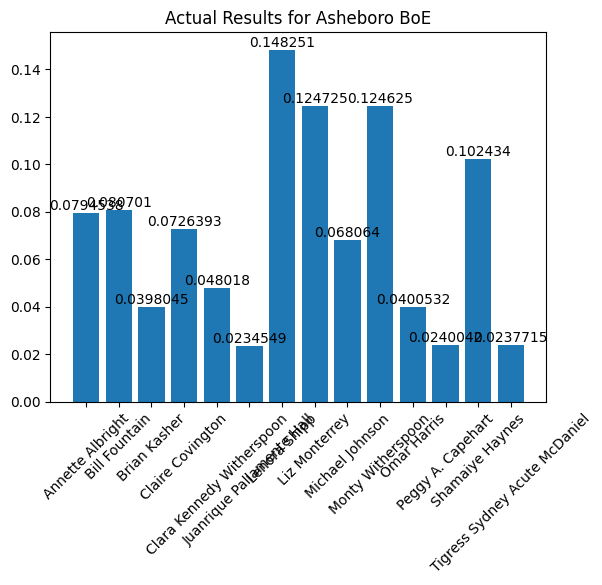

In [25]:
results = pd.read_csv(BASE_DIR / "Election_Data_Sheets" / "csv" / "results_pct_20231107.csv")
results = results[results["Contest Name"] == "CHARLOTTE-MECKLENBURG SCHOOLS BOARD OF EDUCATION AT-LARGE"]
results = results[["Choice", "Total Votes"]]
results = results.groupby("Choice")['Total Votes'].sum().reset_index()
results = results[results["Choice"] != "Write-In (Miscellaneous)"] #Drop Write-Ins, since that's not a choice in the Simulation
results = results[results["Choice"] != "Sean Strain (Write-In)"]
results = results[results["Choice"] != "Stephanie Sneed (Write-In)"]



total_votes = results["Total Votes"].sum()
results["Percentage"] = results["Total Votes"] / total_votes

fig, ax = plt.subplots()
ax.bar(results['Choice'], results['Percentage'])
ax.tick_params(axis='x', labelrotation=45)
plt.title("Actual Results for Asheboro BoE")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show

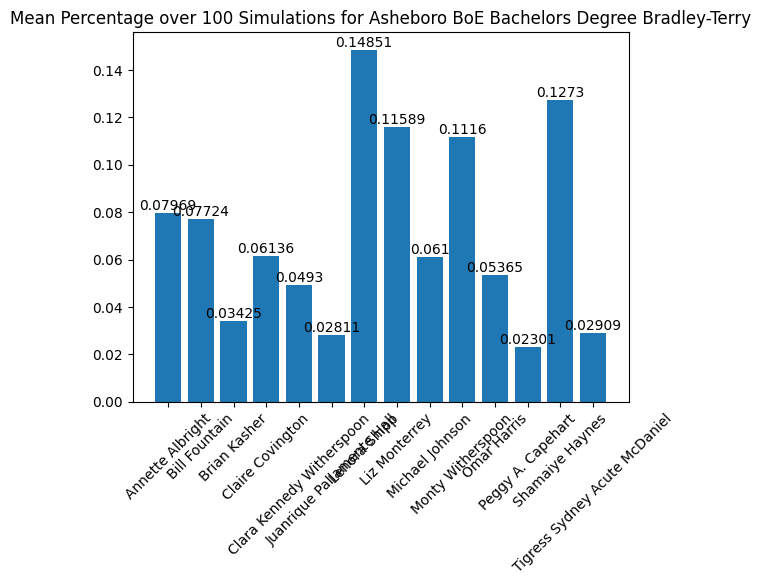

In [26]:
bt_df = pd.read_csv(BASE_DIR / "Results/Ballots/Charlotte Sims/char_sims_Charlotte Board of Education Bachelor's Degree_ballots_BT.csv")
num_winners = 3 #We need to define this per race
num_votes = 1000 #We can calculate this but I'm too lazy to write the code for it right now

# BT
candidates = bt_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

bt_df = pd.concat([candidates, bt_df.drop('ranking', axis=1)], axis=1)

# Store num_candidates for later:
num_candidates = len(candidates.columns)


num_iterations = len(bt_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
bt_df_plur = bt_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_bt = bt_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    bt_df_plur = bt_df[['Vote_1', f'iteration_{i}']]
    temp_df = bt_df_plur.groupby('Vote_1').sum().reset_index()
    final_bt = pd.merge(final_bt, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_bt = final_bt.astype({col: int for col in final_bt.columns[1:]})
final_bt = final_bt.assign(mean=final_bt.mean(axis=1, numeric_only=True))
final_bt['mean_perc'] = final_bt['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_bt['Vote_1'], final_bt['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Bachelors Degree Bradley-Terry")

for container in ax.containers:
    ax.bar_label(container)

plt.show()